# Bilateral Filter Evaluation Results

In [11]:
import os

import matplotlib.pyplot as plt

from evaluate_utils import (
    read_model_results,
    plot_model_loss_all,
    read_performance_results,
    plot_performance_stages,
    compute_performance_speedup,
    print_frame_timing,
    read_quality_results,
    plot_quality_metrics_full,
    print_quality_metrics,
)
from plot_utils import set_plot_style, colors, set_legend_style

RESULTS_DIR = os.path.join('results', 'filter')
RADIANCE_DIR = os.path.join('..', 'data', 'radiance')
EXTINCTIONS = 80, 200, 1000

set_plot_style()

## Model

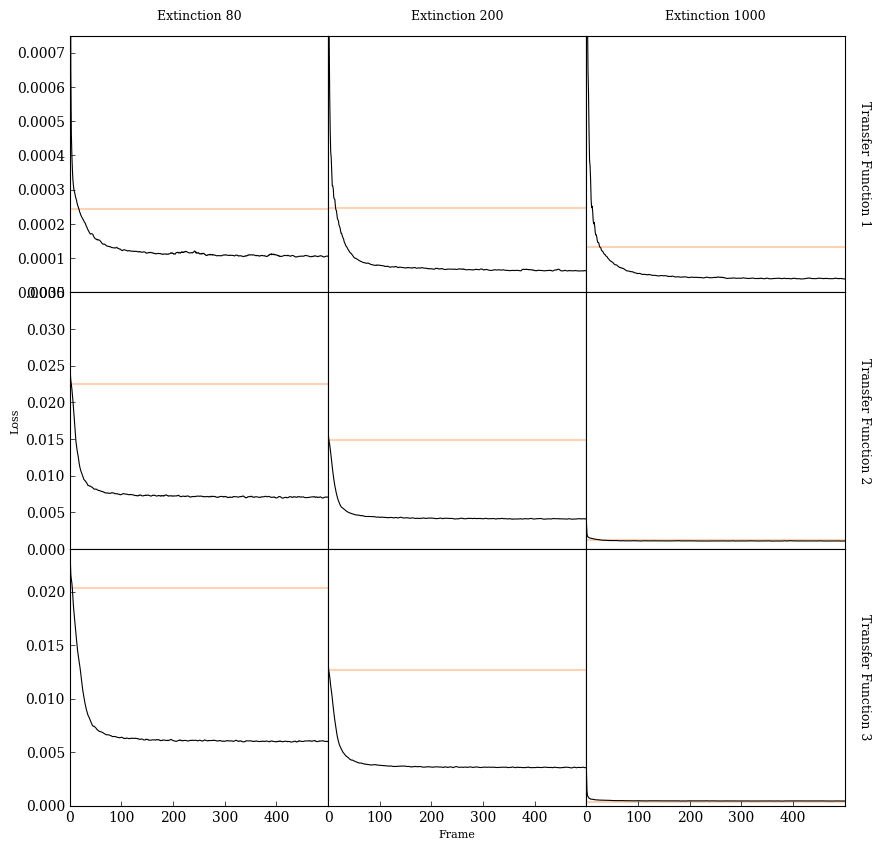

In [12]:
model_results = read_model_results(os.path.join(RESULTS_DIR, 'model'))
ylims = [(0, 0.00075), (0, 0.035), (0, 0.024)]
plot_model_loss_all(model_results, 'chameleon', ylims, show_legend=False)
plt.show()

## Performance

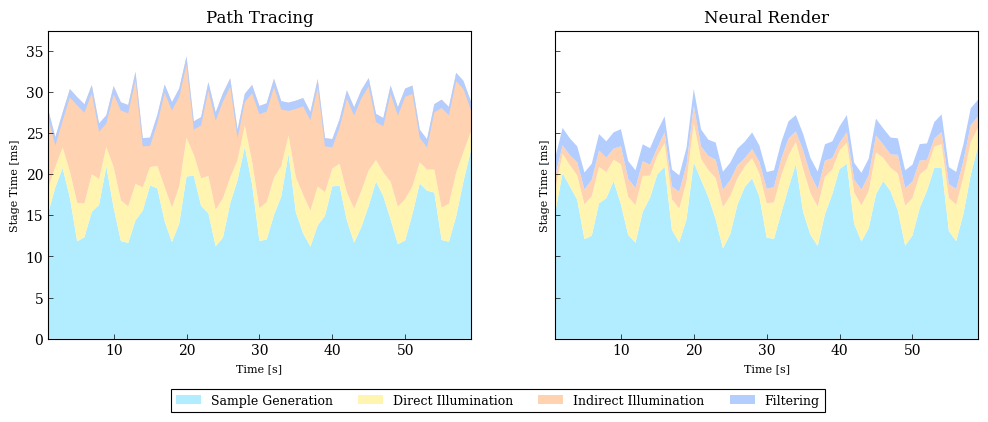

In [13]:
performance_results = {
    'path_tracing': read_performance_results(
        os.path.join(RESULTS_DIR, 'performance', 'path_tracing')
    ),
    'neural_render': read_performance_results(
        os.path.join(RESULTS_DIR, 'performance', 'neural_render')
    ),
}

example = 'chameleon', 1000
stage_cols = ['stage_sample_gen', 'stage_direct', 'stage_indirect', 'stage_filter']
stage_colors = [colors[5], colors[0], colors[2], colors[6]]
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, subdir in enumerate(['path_tracing', 'neural_render']):
    plot_performance_stages(
        ax[i], performance_results[subdir], example, stage_cols, stage_colors
    )
    ax[i].set_title(subdir.replace('_', ' ').title())
    ax[i].set_xlim(1, 59)
    ax[i].set_xlabel('Time [s]')
    ax[i].set_ylabel('Stage Time [ms]')

handles, labels = ax[0].get_legend_handles_labels()
labels = [
    'Sample Generation',
    'Direct Illumination',
    'Indirect Illumination',
    'Filtering',
]
legend = fig.legend(
    handles, labels, ncol=4, bbox_to_anchor=(0.5, 0), loc='upper center'
)
set_legend_style(legend)
plt.show()

In [14]:
timings = compute_performance_speedup(performance_results)
print_frame_timing(timings)

Dataset              Ext.    Ours Frame Time      Ours FPS             PT Frame Time        PT FPS               Speedup
chameleon            80      51.77 ± 0.26         19.37 ± 0.10         50.47 ± 0.39         19.96 ± 0.16         0.97   
                     200     69.39 ± 0.39         14.46 ± 0.08         82.33 ± 0.71         12.27 ± 0.11         1.19   
                     1000    94.71 ± 0.94         10.68 ± 0.10         113.89 ± 0.90        8.84 ± 0.07          1.20   
csafe_heptane        80      17.14 ± 0.74         74.34 ± 3.28         6.85 ± 0.05          146.62 ± 1.00        0.40   
                     200     30.41 ± 0.09         32.92 ± 0.10         28.32 ± 0.46         37.63 ± 1.32         0.93   
                     1000    57.04 ± 0.31         17.59 ± 0.09         65.55 ± 0.51         15.36 ± 0.12         1.15   
marmoset_neurons     80      63.94 ± 0.65         15.83 ± 0.16         63.16 ± 0.78         16.13 ± 0.20         0.99   
                     200     80.

## Quality

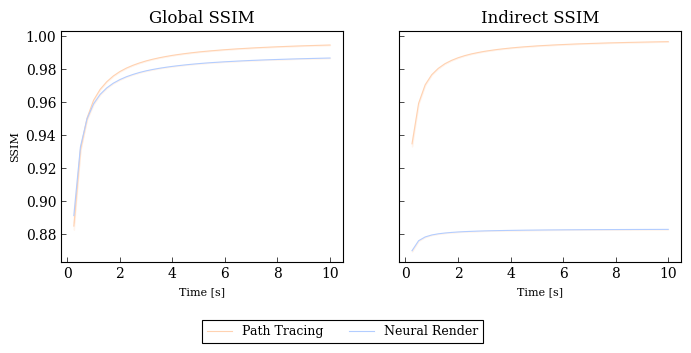

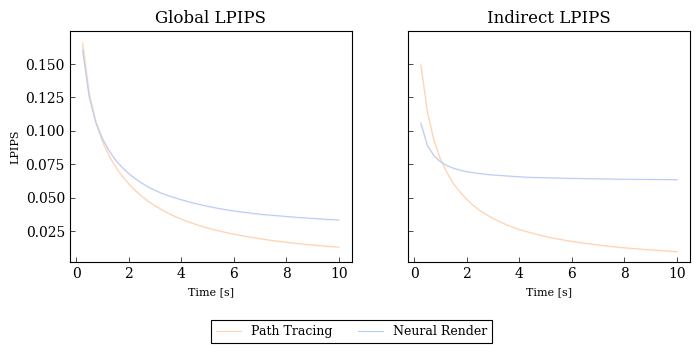

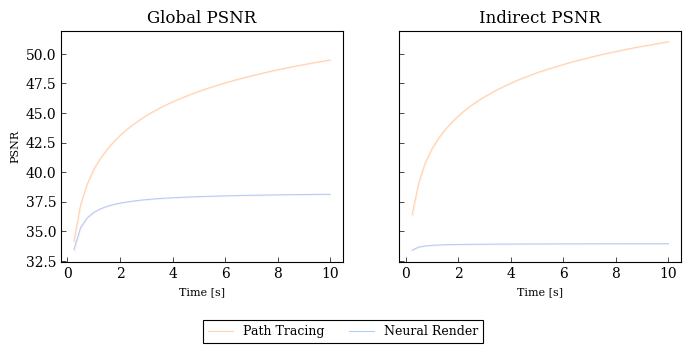

In [15]:
quality_results = read_quality_results(os.path.join(RESULTS_DIR, 'quality'))
plot_quality_metrics_full(quality_results, 'chameleon', 200, 3, 'ssim')
plot_quality_metrics_full(quality_results, 'chameleon', 200, 3, 'lpips')
plot_quality_metrics_full(quality_results, 'chameleon', 200, 3, 'psnr')

In [16]:
print_quality_metrics(quality_results, 'chameleon', 10, 'global')
print_quality_metrics(quality_results, 'chameleon', 10, 'indirect')
print()

print_quality_metrics(quality_results, 'csafe_heptane', 10, 'global')
print_quality_metrics(quality_results, 'csafe_heptane', 10, 'indirect')
print()

print_quality_metrics(quality_results, 'marmoset_neurons', 10, 'global')
print_quality_metrics(quality_results, 'marmoset_neurons', 10, 'indirect')
print()

Volume: chameleon (global)
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
200   3    0.9946 ± 0.0000    0.9867 ± 0.0000    0.0129 ± 0.0001    0.0332 ± 0.0001    49.49 ± 0.01    38.13 ± 0.00
Volume: chameleon (indirect)
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
200   3    0.9966 ± 0.0000    0.8828 ± 0.0000    0.0096 ± 0.0001    0.0634 ± 0.0000    51.03 ± 0.01    33.95 ± 0.00

Volume: csafe_heptane (global)
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
200   3    0.9972 ± 0.0000    0.9836 ± 0.0000    0.0186 ± 0.0001    0.0328 ± 0.0001    53.13 ± 0.01    33.93 ± 0.00
Volume: csafe_heptane (indirect)
Ext.  TF   SSIM PT            SSIM NR            LPIPS PT           LPIPS NR           PSNR PT         PSNR NR        
200   3    0.9981 ± 0.0000    0.8362 ± 0.0000    0.0105